# S1 — Smoke test: Montezuma 1M frames

**Session 1 deliverable.**  Validates that `rnd_baseline/` runs end-to-end on the RTX 4060:
- `mean_ext_return` rises above 0
- `mean_int_reward` is non-flat (real intrinsic signal)
- MP4 eval video is produced
- Interrupt Cell 3 and re-run → resumes from last chunk with no metric jump (P8 test)

Cross-ref: `REBUILD_PLAN.md §5 Session 1`, `HANDOVER.md §d (decision 12)`.

In [2]:
# ── Cell 1: Config ────────────────────────────────────────────────────────────
import sys, os

# Point at rnd_baseline/ so train.py imports resolve
RND_BASE = os.path.abspath(os.path.join(os.path.dirname(os.path.abspath('__file__')), '..', '..'))
if RND_BASE not in sys.path:
    sys.path.insert(0, RND_BASE)

# ── Run parameters ────────────────────────────────────────────────────────────
RUN_NAME     = 'S1_smoke_montezuma_1M'
CONFIG       = 'DEFAULT'          # Montezuma, NumEnv=16
TOTAL_FRAMES = 1000000
CHUNK_FRAMES =   500000          # 2 chunks → 2 resume cycles (validates P8)
SEED         = 42
LOG_INTERVAL = 50                 # log every 50 updates

print(f'Run: {RUN_NAME}  total={TOTAL_FRAMES:,}  chunk={CHUNK_FRAMES:,}')
print(f'rnd_baseline dir: {RND_BASE}')

Run: S1_smoke_montezuma_1M  total=1,000,000  chunk=500,000
rnd_baseline dir: c:\Users\rishe\minor_project_rl\rnd_baseline


In [3]:
# ── Cell 2: Setup ─────────────────────────────────────────────────────────────
# Imports and training context creation.  If a checkpoint exists for this
# run name, it will be loaded automatically (--resume auto).

from train import parse_args, setup_training

args = parse_args([
    '--resume',       'auto',           # load latest.pt if it exists, else start fresh
    '--config',       CONFIG,
    '--total-frames', str(TOTAL_FRAMES),
    '--chunk-frames', str(CHUNK_FRAMES),
    '--run-name',     RUN_NAME,
    '--seed',         str(SEED),
    '--log-interval', str(LOG_INTERVAL),
])

ctx = setup_training(args)
print(f'\nSetup complete.  global_step={ctx.global_step:,} / {TOTAL_FRAMES:,}')

[2026-05-15 09:17:58] run=S1_smoke_montezuma_1M  config=DEFAULT  total_frames=1000000  chunk=500000  seed=42  config_hash=eb75a940fa43cc6a6d12014a1f49bfbae9f9d182


c:\Users\rishe\minor_project_rl\rnd_baseline\train.py:138: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(resume_path, map_location='cpu')


[ckpt] resumed from step 1,003,520  (c:\Users\rishe\minor_project_rl\rnd_baseline\runs\S1_smoke_montezuma_1M\checkpoints\latest.pt)
[2026-05-15 09:18:02] Resumed from step 1,003,520
[2026-05-15 09:18:02] Spawning 16 env workers for MontezumaRevengeNoFrameskip-v4…
[2026-05-15 09:19:49] Workers started.

Setup complete.  global_step=1,003,520 / 1,000,000


In [3]:
# ── Cell 3: Train ─────────────────────────────────────────────────────────────
# Runs chunk by chunk until total_frames is reached.
# Safe to interrupt between chunks (checkpoint saved at each chunk end).
# Re-running this cell after an interrupt resumes from the last checkpoint.

from train import train_one_chunk

while ctx.global_step < args.total_frames:
    print(f'\n>>> Starting chunk from step {ctx.global_step:,}')
    train_one_chunk(ctx)
    print(f'    Chunk done. step={ctx.global_step:,}  best_ext={ctx.best_ext_so_far:.2f}')

print('\n=== Training complete ===')


>>> Starting chunk from step 0
[2026-05-15 04:25:25] --- chunk start: step=0  target=500,000 ---
[2026-05-15 04:37:54] step=   102,400  fps=   137  ext_ret=   0.00  int_rew=17.38347  ploss= 0.0081  ent=2.7674  gnorm=0.1450
[2026-05-15 04:48:43] step=   204,800  fps=   146  ext_ret=   0.00  int_rew=11.85904  ploss= 0.0033  ent=2.8463  gnorm=0.1206
[2026-05-15 04:57:22] step=   307,200  fps=   160  ext_ret=   0.00  int_rew=10.65860  ploss=-0.0089  ent=2.8519  gnorm=0.0880
[2026-05-15 05:03:25] step=   409,600  fps=   180  ext_ret=   0.00  int_rew=10.96709  ploss=-0.0067  ent=2.7365  gnorm=0.1793
[ckpt] saved → c:\Users\rishe\minor_project_rl\rnd_baseline\runs\S1_smoke_montezuma_1M\checkpoints\chunk_00000501760.pt


c:\Users\rishe\anaconda3\envs\rnd_env\lib\site-packages\gym\wrappers\record_video.py:41: UserWarning: WARN: Overwriting existing videos at c:\Users\rishe\minor_project_rl\rnd_baseline\runs\S1_smoke_montezuma_1M\videos\eval_step_00000501760 folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


[2026-05-15 05:09:14] [eval] step=501,760  mean_return=0.00±0.00  mean_ep_len=2496  video → c:\Users\rishe\minor_project_rl\rnd_baseline\runs\S1_smoke_montezuma_1M\videos\eval_step_00000501760
[2026-05-15 05:09:14] --- chunk done: step=501,760 ---
    Chunk done. step=501,760  best_ext=0.00

>>> Starting chunk from step 501,760
[2026-05-15 05:09:14] --- chunk start: step=501,760  target=1,001,760 ---
[2026-05-15 05:09:45] step=   512,000  fps=   331  ext_ret=   0.00  int_rew=11.07193  ploss=-0.0108  ent=2.7346  gnorm=0.1849
[2026-05-15 05:14:53] step=   614,400  fps=   332  ext_ret=   0.00  int_rew= 9.34823  ploss=-0.0020  ent=2.5803  gnorm=0.0882
[2026-05-15 05:21:25] step=   716,800  fps=   294  ext_ret=   0.00  int_rew= 7.96522  ploss= 0.0000  ent=2.5978  gnorm=0.0960
[2026-05-15 05:30:14] step=   819,200  fps=   252  ext_ret=   0.00  int_rew= 8.49794  ploss= 0.0075  ent=2.6899  gnorm=0.2237
[2026-05-15 05:36:48] step=   921,600  fps=   254  ext_ret=   0.00  int_rew= 7.22075  ploss=

c:\Users\rishe\anaconda3\envs\rnd_env\lib\site-packages\gym\wrappers\record_video.py:41: UserWarning: WARN: Overwriting existing videos at c:\Users\rishe\minor_project_rl\rnd_baseline\runs\S1_smoke_montezuma_1M\videos\eval_step_00001003520 folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


[2026-05-15 05:42:38] [eval] step=1,003,520  mean_return=0.00±0.00  mean_ep_len=4426  video → c:\Users\rishe\minor_project_rl\rnd_baseline\runs\S1_smoke_montezuma_1M\videos\eval_step_00001003520
[2026-05-15 05:42:38] --- chunk done: step=1,003,520 ---
    Chunk done. step=1,003,520  best_ext=0.00

=== Training complete ===


In [ ]:
# ── Cell 4: Eval ──────────────────────────────────────────────────────────────
# Run a standalone eval using the latest checkpoint and record a fresh video.
# (eval_checkpoint is also called automatically at each chunk end inside
#  train_one_chunk, so a video already exists; this cell re-runs it manually.)

from train import eval_checkpoint

eval_checkpoint(ctx, n_episodes=3)

import os
vid_root = os.path.join(ctx.video_dir)
for root, dirs, files in os.walk(vid_root):
    for f in files:
        if f.endswith('.mp4'):
            print('Video:', os.path.join(root, f))

Loaded 9 log records
   global_step  mean_ext_return  mean_int_reward  policy_loss   entropy  grad_norm
0       102400              0.0        17.383467     0.008099  2.767405   0.144996
1       204800              0.0        11.859043     0.003327  2.846264   0.120648
2       307200              0.0        10.658596    -0.008868  2.851921   0.087954
3       409600              0.0        10.967092    -0.006653  2.736460   0.179262
4       512000              0.0        11.071928    -0.010812  2.734604   0.184879
5       614400              0.0         9.348231    -0.002002  2.580256   0.088191
6       716800              0.0         7.965220     0.000043  2.597820   0.095951
7       819200              0.0         8.497942     0.007528  2.689865   0.223662
8       921600              0.0         7.220748    -0.001048  2.683208   0.063551


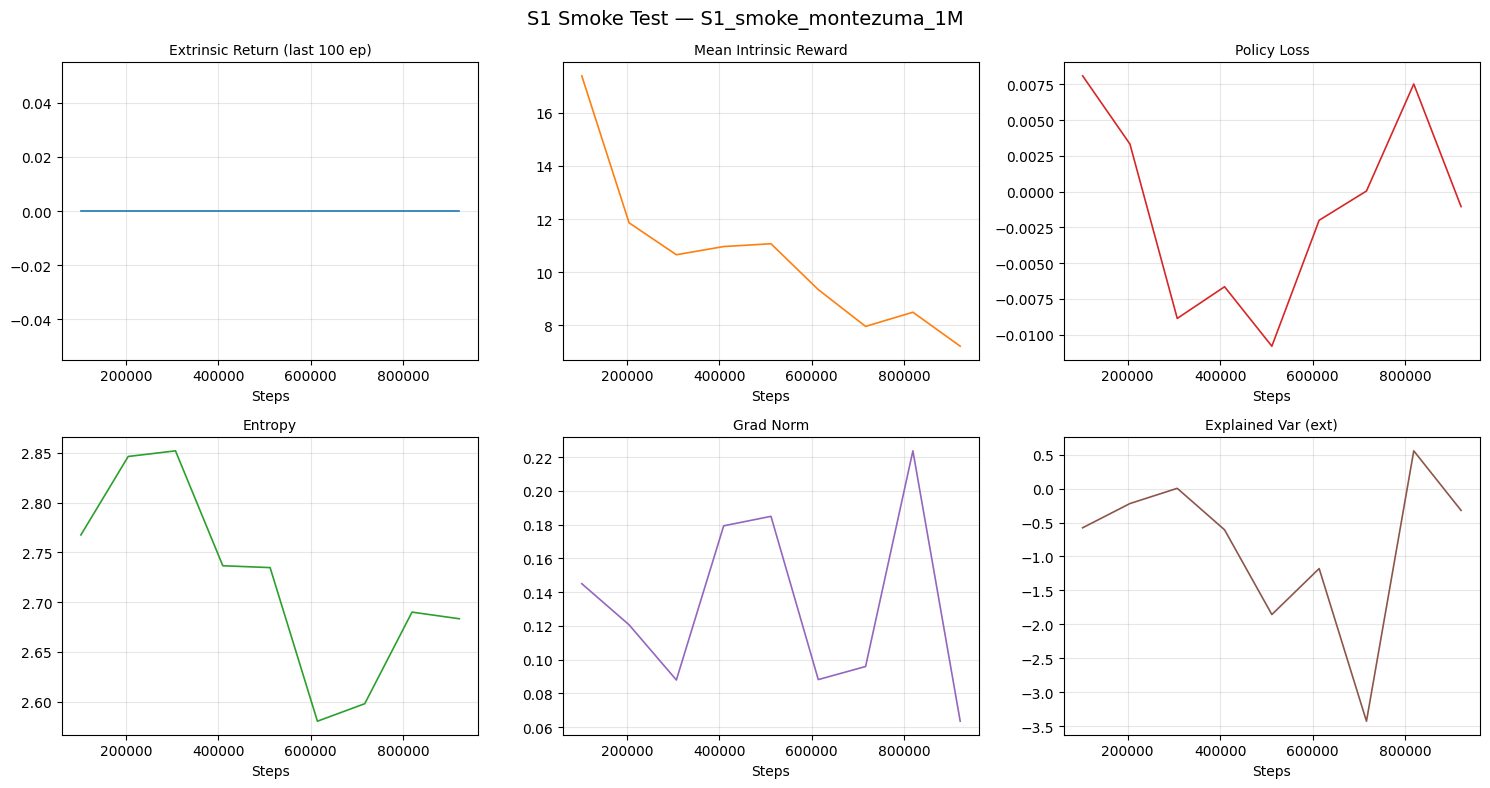

Saved → c:\Users\rishe\minor_project_rl\rnd_baseline\runs\S1_smoke_montezuma_1M\S1_smoke_plots.png


In [5]:
# ── Cell 5: Plots ─────────────────────────────────────────────────────────────
import json
import pandas as pd
import matplotlib.pyplot as plt
import os

metrics_path = os.path.join(ctx.run_dir, 'logs', 'metrics.jsonl')

records = []
with open(metrics_path) as f:
    for line in f:
        line = line.strip()
        if line:
            records.append(json.loads(line))

df = pd.DataFrame(records)
print(f'Loaded {len(df)} log records')
print(df[['global_step', 'mean_ext_return', 'mean_int_reward',
          'policy_loss', 'entropy', 'grad_norm']].tail(10).to_string())

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle(f'S1 Smoke Test — {RUN_NAME}', fontsize=14)

plots = [
    ('mean_ext_return',  'Extrinsic Return (last 100 ep)', 'tab:blue'),
    ('mean_int_reward',  'Mean Intrinsic Reward',          'tab:orange'),
    ('policy_loss',      'Policy Loss',                    'tab:red'),
    ('entropy',          'Entropy',                        'tab:green'),
    ('grad_norm',        'Grad Norm',                      'tab:purple'),
    ('explained_var_ext','Explained Var (ext)',            'tab:brown'),
]

for ax, (col, title, color) in zip(axes.flat, plots):
    if col in df.columns:
        ax.plot(df['global_step'], df[col], color=color, linewidth=1.2)
        ax.set_title(title, fontsize=10)
        ax.set_xlabel('Steps')
        ax.grid(True, alpha=0.3)
    else:
        ax.text(0.5, 0.5, f'{col}\nnot in log', ha='center', va='center')

plt.tight_layout()
plot_path = os.path.join(ctx.run_dir, 'S1_smoke_plots.png')
plt.savefig(plot_path, dpi=120)
plt.show()
print(f'Saved → {plot_path}')

## Cell 6 — Notes

*(Fill in after running)*

**CHECKPOINT 1 checklist (must pass before Session 2):**
- [ ] `mean_ext_return` rises above 0 within 1M frames
- [ ] `mean_int_reward` is non-flat (variance > 0 across envs)
- [ ] No NaN in any loss, no shape errors
- [ ] MP4 eval video exists under `runs/S1_smoke_montezuma_1M/videos/`
- [ ] Interrupt Cell 3 mid-run, re-run → resumes from last chunk with no metric jump

**Observations:**

- Final `mean_ext_return` @ 1M steps: _
- `mean_int_reward` behaviour: _
- Any warnings / errors: _
- Wall-clock for 1M frames on RTX 4060: _
- FPS estimate from logs: _